# SmartSegment Auto

Optimisation de la stratégie marketing de l'entreprise par segmentation client.

dataset : https://www.kaggle.com/datasets/vetrirah/customer

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier

import joblib

In [135]:
df = pd.read_csv('./data/Train.csv')

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


Affichage des 5 premières lignes du dataset.

Nous avons les variables suivantes :
- ID : ID de l'application source, ne sera pas utilisé ;
- Gender : le genre de la personne : Homme ou femme ;
- Ever_Married : La personne a t elle déja été mariée ;
- Age : l'age ;
- Graduated : la personne est-elle diplomée ;
- Work_Experience : nombre d'années d'experience au travail ;
- Spending_Score : score de dépense de l'utilisateur
- Family_Size : taille de la famille ;
- Var_1 : **une catégorie anonymisée** pour la conformité RGPD / CNIL ;
- Segmentation : notre **label** : le segment de l'utilisateur (A, B, C, D). C'est ceci qu'il faudra prédire.

## Structure des données

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


Nous avons 8067 lignes dans ce dataset.

- les variables `Age`, `Work_Experience` et `Family_Size` sont des variables quantitative (numérique) ;
- les variables `Gender`, `Graduated`, `Profession`, `Spending_Score` et `Var_1` sont des variables qualitatives (des catégories).
- la variable `Segmentation` est notre label, 4 catégories : A, B, C et D.

In [137]:
# suppression de la colonne ID, renommage des colonnes en minuscule

df = df.drop(columns="ID").rename(
    columns={
        "Gender": "gender",
        "Ever_Married": "ever_married",
        "Age": "age",
        "Graduated": "graduated",
        "Profession": "profession",
        "Work_Experience": "work_experience",
        "Spending_Score": "spending_score",
        "Family_Size": "family_size",
        "Var_1": "var_1",
        "Segmentation": "segmentation",
    }
).copy()

df.sample(n=5)

,gender,ever_married,age,graduated,profession,work_experience,spending_score,family_size,var_1,segmentation
643,Female,No,19,No,Healthcare,0.0,Low,3.0,Cat_6,D
1980,Male,Yes,39,Yes,Artist,0.0,Average,2.0,Cat_2,C
4453,Male,Yes,53,Yes,Healthcare,3.0,High,4.0,Cat_7,B
7283,Male,No,31,Yes,Marketing,0.0,Low,2.0,Cat_3,D
5630,Male,No,33,No,Doctor,0.0,Low,3.0,Cat_6,B


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           8068 non-null   str    
 1   ever_married     7928 non-null   str    
 2   age              8068 non-null   int64  
 3   graduated        7990 non-null   str    
 4   profession       7944 non-null   str    
 5   work_experience  7239 non-null   float64
 6   spending_score   8068 non-null   str    
 7   family_size      7733 non-null   float64
 8   var_1            7992 non-null   str    
 9   segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 630.4 KB


Nous avons des données manquantes, nous les traiterons ultérieurement.

Regardons les répartitions de données :

<Axes: xlabel='gender'>

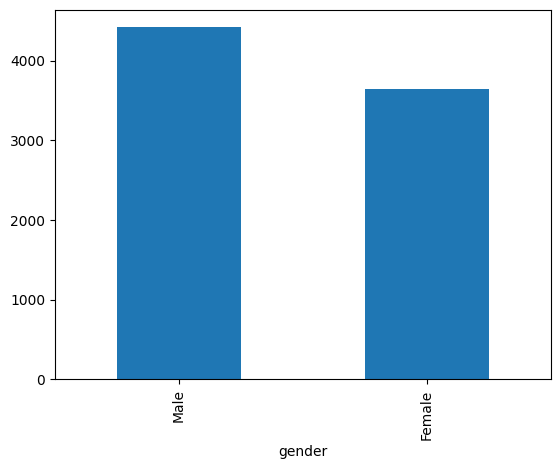

In [139]:
df['gender'].value_counts().plot.bar()

<Axes: xlabel='ever_married'>

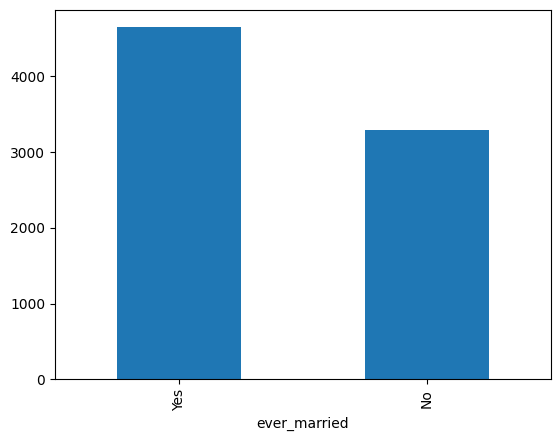

In [140]:
df['ever_married'].value_counts().plot.bar()

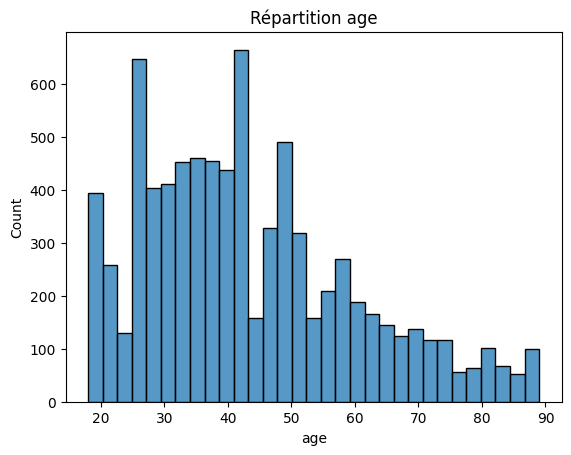

In [141]:
plt.figure()
sns.histplot(data=df["age"])
plt.title(f"Répartition age")
plt.show()

<Axes: xlabel='graduated'>

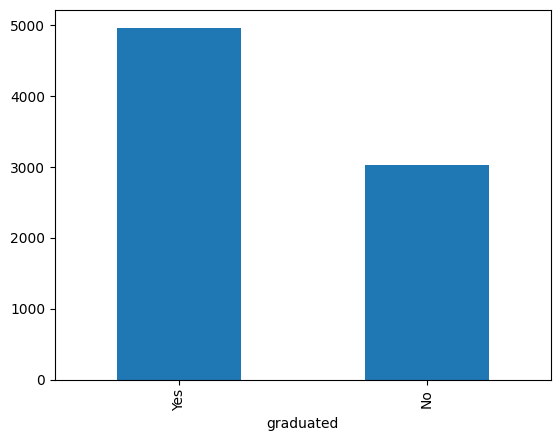

In [142]:
df['graduated'].value_counts().plot.bar()

<Axes: xlabel='profession'>

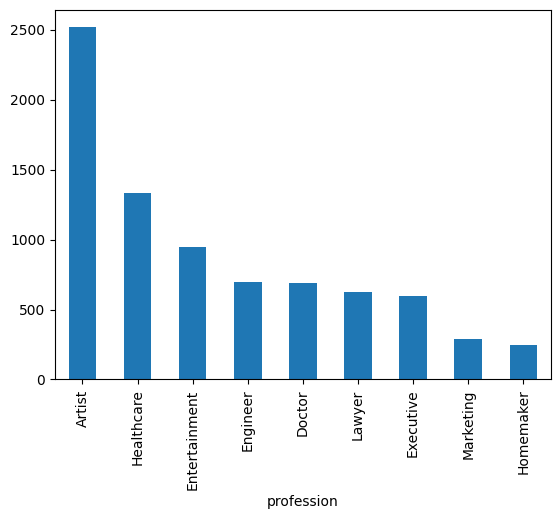

In [143]:
df['profession'].value_counts().plot.bar()

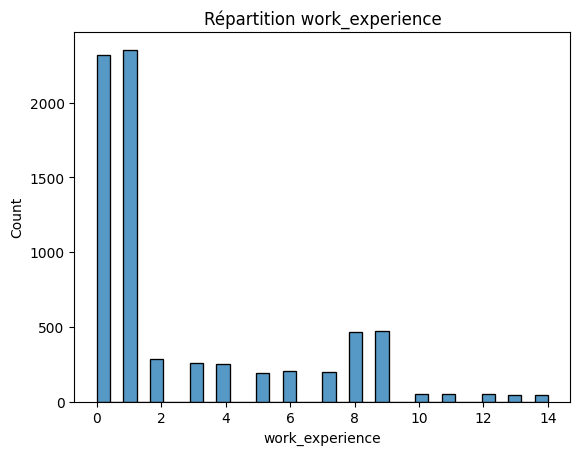

In [144]:
plt.figure()
sns.histplot(data=df["work_experience"])
plt.title(f"Répartition work_experience")
plt.show()

<Axes: xlabel='spending_score'>

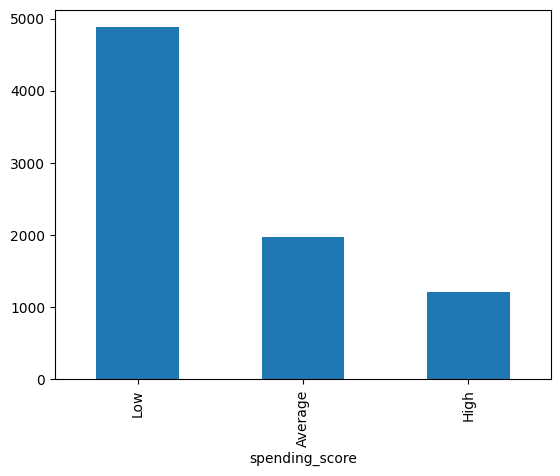

In [145]:
df['spending_score'].value_counts().plot.bar()

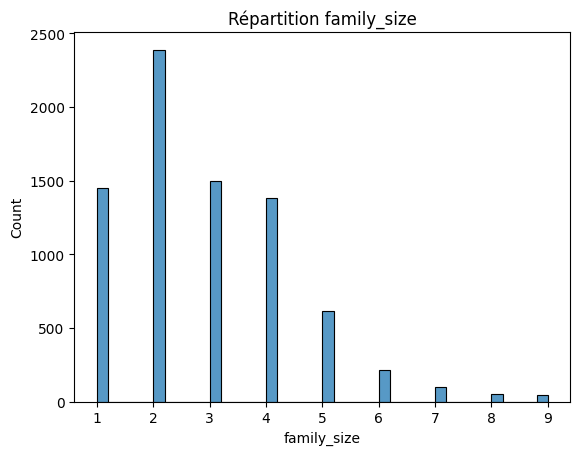

In [146]:
plt.figure()
sns.histplot(data=df["family_size"])
plt.title(f"Répartition family_size")
plt.show()

<Axes: xlabel='var_1'>

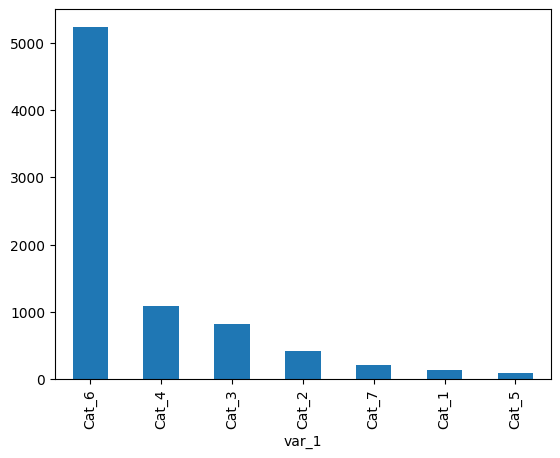

In [147]:
df['var_1'].value_counts().plot.bar()

<Axes: xlabel='segmentation'>

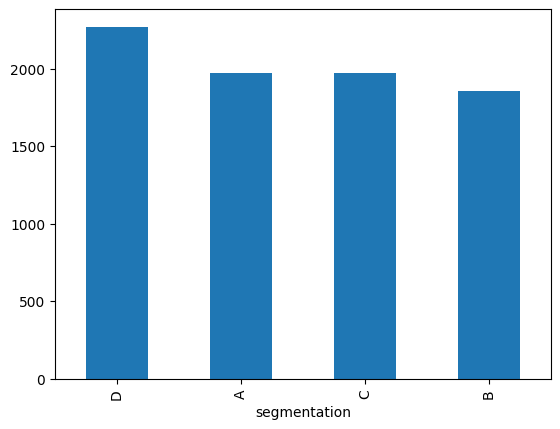

In [148]:
df['segmentation'].value_counts().plot.bar()

In [149]:
df.describe(include="all")

,gender,ever_married,age,graduated,profession,work_experience,spending_score,family_size,var_1,segmentation
count,8068,7928,8068.000000,7990,7944,7239.000000,8068,7733.000000,7992,8068
unique,2,2,NaN,2,9,NaN,3,NaN,7,4
top,Male,Yes,NaN,Yes,Artist,NaN,Low,NaN,Cat_6,D
freq,4417,4643,NaN,4968,2516,NaN,4878,NaN,5238,2268
mean,NaN,NaN,43.466906,NaN,NaN,2.641663,NaN,2.850123,NaN,NaN
std,NaN,NaN,16.711696,NaN,NaN,3.406763,NaN,1.531413,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,0.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,30.000000,NaN,NaN,0.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,40.000000,NaN,NaN,1.000000,NaN,3.000000,NaN,NaN
75%,NaN,NaN,53.000000,NaN,NaN,4.000000,NaN,4.000000,NaN,NaN


## Traitement des valeurs manquantes

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           8068 non-null   str    
 1   ever_married     7928 non-null   str    
 2   age              8068 non-null   int64  
 3   graduated        7990 non-null   str    
 4   profession       7944 non-null   str    
 5   work_experience  7239 non-null   float64
 6   spending_score   8068 non-null   str    
 7   family_size      7733 non-null   float64
 8   var_1            7992 non-null   str    
 9   segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 630.4 KB


In [151]:
df.isnull().sum()

gender               0
ever_married       140
age                  0
graduated           78
profession         124
work_experience    829
spending_score       0
family_size        335
var_1               76
segmentation         0
dtype: int64

Pour nos données catégorielles, nous remplaçons les valeurs manquantes par la valeur la plus fréquente

In [152]:
for col in ["ever_married", "graduated", "profession", "var_1"]:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

Pour les données quantitatives, nous remplaçons par la médiane

In [153]:
df.loc[:, "work_experience"] = df["work_experience"].fillna(df["work_experience"].median())
df.loc[:, "family_size"] = df["family_size"].fillna(df["family_size"].median())

In [154]:
df.isnull().sum()

gender             0
ever_married       0
age                0
graduated          0
profession         0
work_experience    0
spending_score     0
family_size        0
var_1              0
segmentation       0
dtype: int64

Nous en avons terminé avec les données manquantes.

## Détection des problèmes dans les données

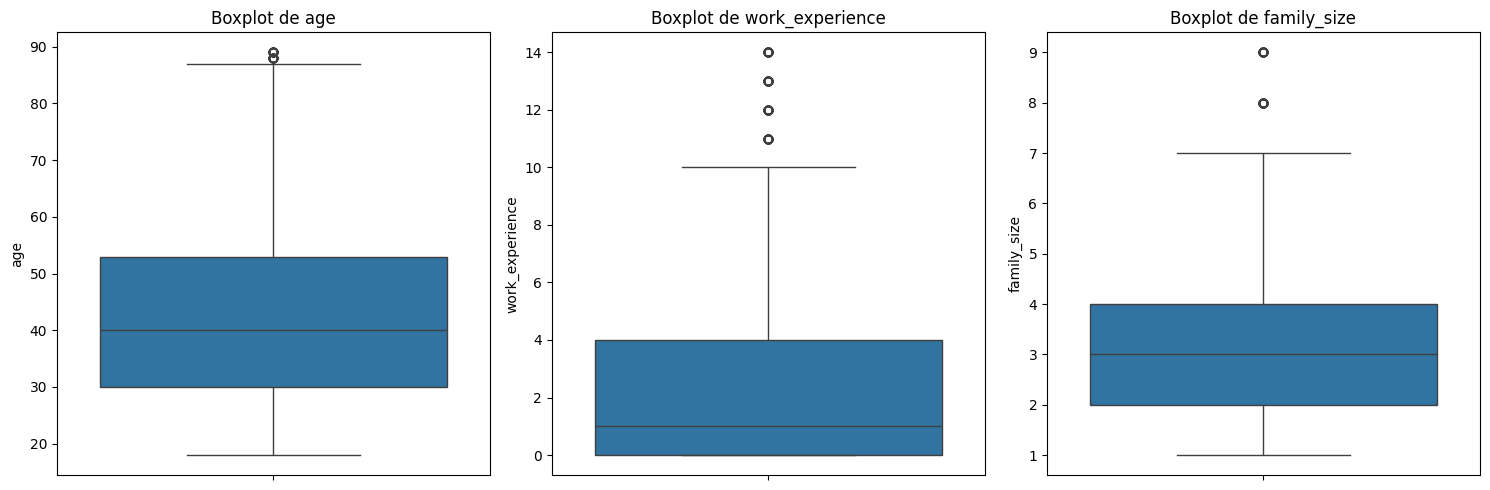

In [155]:
variables_quantitatives = ["age", "work_experience", "family_size"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_quantitatives):
    sns.boxplot(data=df, y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

Nous avons des **outliers**, des données aberrentes. Nous allons les traiter en nous basant sur l'écart inter quartil (IQR). Dès que la donnée est supérieure à Q3 + (1.5 * IQR), nous remplaçons par cette limite. De même pour la partie limite basse Q1 - (1.5 * IQR).

In [156]:
for variable in variables_quantitatives:

    # calcul IQR    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    # limites basse / haute
    limite_basse = Q1 - 1.5 * IQR
    limite_haute = Q3 + 1.5 * IQR

    df[variable] = np.where(df[variable] < limite_basse, limite_basse, df[variable])
    df[variable] = np.where(df[variable] > limite_haute, limite_haute, df[variable])

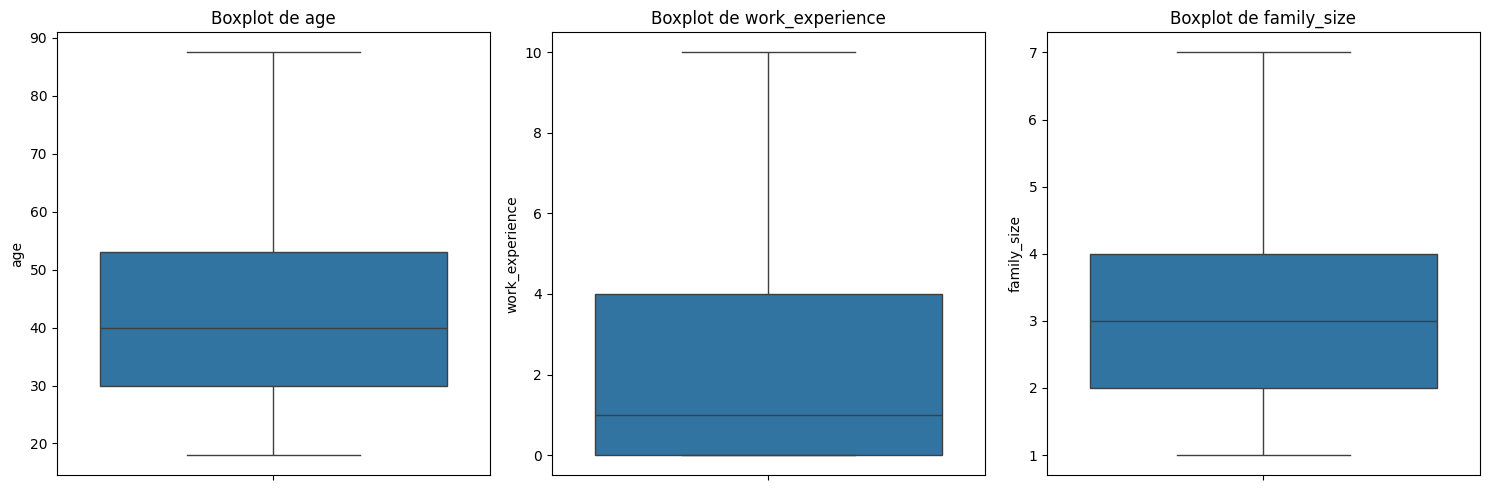

In [157]:
variables_quantitatives = ["age", "work_experience", "family_size"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_quantitatives):
    sns.boxplot(data=df, y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

Nous avons traité les outliers.

## Analyse et corrélations

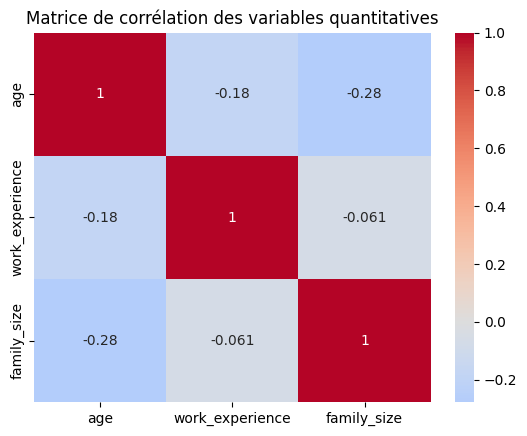

In [158]:
plt.figure()
sns.heatmap(df[variables_quantitatives].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

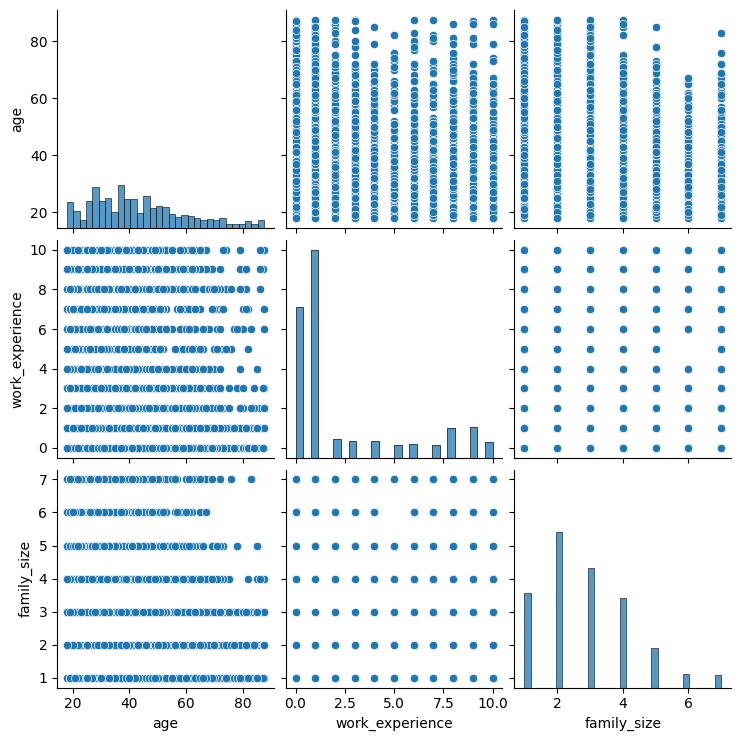

In [159]:
sns.pairplot(df[variables_quantitatives])
plt.show()

il ne semble pas y avoir de corrélations entre nos variables quantitatives.

## Modélisation

### Choix des variables

nous allons selectionner les variables suivantes pour nos modèles et leurs appliquer le traitement correspondant :

| variable        | commentaire                                               |
| --------------- | --------------------------------------------------------- |
| age             | Feature, quantitative, à normaliser avec `StandardScaler` |
| work_experience | Feature, quantitative, à normaliser avec `StandardScaler` |
| family_size     | Feature, quantitative, à normaliser avec `StandardScaler` |
| gender          | Feature. Traitement en one hot encoding (2 modalités)     |
| ever_married    | Feature. Traitement en one hot encoding (2 modalités)     |
| graduated       | Feature. Traitement en one hot encoding (2 modalités)     |
| profession      | Feature. Traitement en one hot encoding (9 modalités)     |
| spending_score  | Feature. Traitement en one hot encoding (3 modalités)     |
| var_1           | Feature. Traitement en one hot encoding (7 modalités)     |

Cela fera donc **28 dimensions suite au one hot encoding.**

In [160]:
variables_qualitatives = ["gender", "ever_married", "graduated", "profession", "spending_score", "var_1"]

variables_quant_qual = variables_quantitatives + variables_qualitatives

df = df[variables_quant_qual + ["segmentation"]]

df.sample(n=5)

,age,work_experience,family_size,gender,ever_married,graduated,profession,spending_score,var_1,segmentation
4960,37.0,9.0,2.0,Female,Yes,Yes,Doctor,Average,Cat_6,C
7169,42.0,3.0,2.0,Male,No,Yes,Entertainment,Low,Cat_2,A
4033,37.0,1.0,1.0,Female,No,Yes,Healthcare,Low,Cat_6,B
4558,31.0,1.0,3.0,Male,No,No,Healthcare,Low,Cat_6,D
5061,73.0,1.0,2.0,Female,Yes,No,Lawyer,Low,Cat_6,B


### Traitement des variables

- normalisation `StandardScaler()` pour les variables quantitatives
- One hot enconding `OneHotEncoder()` pour les variables qualitatives

In [161]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_quantitatives),
        (
            "cat",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            variables_qualitatives,
        ),
    ],
    remainder="drop",
)

In [163]:
X = df[variables_quant_qual]

y = df["segmentation"]

In [164]:
X_encoded = preprocessor.fit_transform(X)

# nouveaux nom de colonnes

columns_one_hot = preprocessor.named_transformers_["cat"].get_feature_names_out(variables_qualitatives)

columns = variables_quantitatives + list(columns_one_hot)

df_features = pd.DataFrame(X_encoded, columns=columns)
df_features


,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_Average,spending_score_High,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,-1.285917,-0.778742,2.886080,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8064,-0.506866,0.188452,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8065,-0.626720,-0.456344,-1.275777,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8066,-0.986282,-0.456344,0.805152,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### DataFrame final

In [165]:
df_final = pd.concat([df_features, y])
df_final

,age,work_experience,family_size,gender_Female,gender_Male,ever_married_No,ever_married_Yes,graduated_No,graduated_Yes,profession_Artist,...,spending_score_High,spending_score_Low,var_1_Cat_1,var_1_Cat_2,var_1_Cat_3,var_1_Cat_4,var_1_Cat_5,var_1_Cat_6,var_1_Cat_7,segmentation
0,-1.285917,-0.456344,0.805152,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN
1,-0.327084,-0.456344,0.111509,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN
2,1.410800,-0.456344,-1.275777,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
3,1.410800,-0.778742,-0.582134,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
4,-0.207230,-0.456344,2.192437,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D
8064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D
8065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D
8066,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
